In [6]:
# ============================================================
# CELL 1: INSTALL AND IMPORT LIBRARIES
# ============================================================

!pip install -q numpy pandas scipy scikit-image tifffile matplotlib openpyxl

import os
import json
import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from skimage.draw import polygon
from skimage.measure import label as cc_label, regionprops
from matplotlib.colors import ListedColormap

In [13]:
# @title
# ============================================================
# CELL 2: USER SETTINGS
# ============================================================

INPUT_EXCEL = "/content/drive/MyDrive/NIST Data Lables/GD Parameters with Inverse Calibrated wLAC - BUHASA Compounds.xlsx"

OUTPUT_DIR = "/content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle"

COMPOUND_COL = "Compound"
mu_cols = ["wLAC_1", "wLAC_2", "wLAC_3", "wLAC_4", "wLAC_5"]
PROBABILITY_COL = "Probability"

k_bins = np.array([0.130, 0.128, 0.130, 0.128, 0.117], dtype=np.float32)

IMAGE_H = 1262
IMAGE_W = 1262
N_BINS = 5

# Central circular rock/sample region
CENTER_RADIUS = 300
BACKGROUND_ID = 0

# Dataset size
NUM_IMAGES = 1000

# Voronoi mineral grains
NUM_VORONOI_SEEDS = 900

# Air / pore settings
AIR_NAME_KEYWORD = "air"
#NUM_PORES = 300
#PORE_RADIUS_RANGE = (10, 20)
#CLUSTER_PROBABILITY = 0.50
#CLUSTER_OFFSET_RANGE = (2, 10)

# Gaussian Random Field porosity settings
TARGET_POROSITY = 0.30     # % air inside circular rock region
GRF_SIGMA = 8              # controls pore smoothness/connectivity

# Gaussian sampling
CLIP_NEGATIVE_LAC = True

# Reproducibility
RANDOM_SEED = 50

**Output Folders**

In [14]:
# @title
# ============================================================
# CELL 3: CREATE OUTPUT FOLDERS
# ============================================================

images_tiff_dir = os.path.join(OUTPUT_DIR, "images_tiff")
images_npy_dir  = os.path.join(OUTPUT_DIR, "images_npy")

labels_tiff_dir = os.path.join(OUTPUT_DIR, "labels_tiff")
labels_npy_dir  = os.path.join(OUTPUT_DIR, "labels_npy")
labels_png_dir  = os.path.join(OUTPUT_DIR, "labels_png")

plots_dir       = os.path.join(OUTPUT_DIR, "validation_plots")
reports_dir     = os.path.join(OUTPUT_DIR, "health_reports")

for d in [
    images_tiff_dir,
    images_npy_dir,
    labels_tiff_dir,
    labels_npy_dir,
    labels_png_dir,
    plots_dir,
    reports_dir
]:
    os.makedirs(d, exist_ok=True)

print("Output folders created at:")
print(OUTPUT_DIR)

Output folders created at:
/content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle


In [15]:
# @title
# ============================================================
# CELL 4: LOAD MATERIAL PARAMETERS FROM EXCEL
# ============================================================

df = pd.read_excel(INPUT_EXCEL)

required_cols = [COMPOUND_COL] + mu_cols + [PROBABILITY_COL]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns in Excel: {missing}")

df = df[required_cols].copy()
df = df.dropna(subset=[COMPOUND_COL] + mu_cols).reset_index(drop=True)

df[COMPOUND_COL] = df[COMPOUND_COL].astype(str)

material_names = df[COMPOUND_COL].tolist()

mu_table = df[mu_cols].values.astype(np.float32)

# sigma = k * mu
sigma_table = np.abs(mu_table) * k_bins[None, :]

# Material IDs start from 1
material_to_id = {name: i + 1 for i, name in enumerate(material_names)}
id_to_material = {i + 1: name for i, name in enumerate(material_names)}

# Detect Air row
air_candidates = [
    name for name in material_names
    if AIR_NAME_KEYWORD.lower() in name.lower()
]

if len(air_candidates) == 0:
    raise ValueError(
        "No Air material found in Excel. "
        "Please add a row named Air with wLAC_1 to wLAC_5 values."
    )

AIR_NAME = air_candidates[0]
AIR_ID = material_to_id[AIR_NAME]

# Minerals exclude Air
mineral_names = [m for m in material_names if m != AIR_NAME]
mineral_ids = np.array([material_to_id[m] for m in mineral_names], dtype=np.int32)

print("Materials loaded:")
for mid, name in id_to_material.items():
    print(f"{mid}: {name}")

print("\nColumns in the DataFrame:")
print(df.columns.tolist())

print("\nDetected air/pore material:")
print(f"{AIR_NAME} | Label ID = {AIR_ID}")

print("\nMean LAC table shape:", mu_table.shape)
print("Sigma table shape:", sigma_table.shape)

Materials loaded:
1: CaCO₃
2: CaMg(CO₃)₂
3: SiO₂
4: KAlSi₃O₈
5: Fe₂O₃
6: NaCl
7: CaSO₄·2H₂O
8: CaSO₄
9: Al₂Si₂O₅(OH)₄
10: Air

Columns in the DataFrame:
['Compound', 'wLAC_1', 'wLAC_2', 'wLAC_3', 'wLAC_4', 'wLAC_5', 'Probability']

Detected air/pore material:
Air | Label ID = 10

Mean LAC table shape: (10, 5)
Sigma table shape: (10, 5)


**Custom Material Probabilities from Excel**

In [17]:
# @title
# ============================================================
# CELL 5: MATERIAL PROBABILITIES FROM EXCEL
# ============================================================

if PROBABILITY_COL not in df.columns:
    raise ValueError(
        f"Column '{PROBABILITY_COL}' not found in Excel."
    )

# Remove Air because pores are generated separately
mineral_df = df[
    df[COMPOUND_COL] != AIR_NAME
].copy()

mineral_names = mineral_df[COMPOUND_COL].tolist()

mineral_ids = np.array(
    [material_to_id[m] for m in mineral_names],
    dtype=np.int32
)

mineral_probs = mineral_df[
    PROBABILITY_COL
].values.astype(np.float64)

if np.any(mineral_probs < 0):
    raise ValueError(
        "Negative probabilities found in Excel."
    )

if mineral_probs.sum() == 0:
    raise ValueError(
        "All probabilities are zero."
    )

# Normalize automatically
mineral_probs = mineral_probs / mineral_probs.sum()

print("Material Probabilities:")

for name, prob in zip(mineral_names, mineral_probs):
    print(f"{name:<25s} {prob:.4f}")

print("\nSum =", mineral_probs.sum())

Material Probabilities:
CaCO₃                     0.5000
CaMg(CO₃)₂                0.3000
SiO₂                      0.0800
KAlSi₃O₈                  0.0300
Fe₂O₃                     0.0100
NaCl                      0.0100
CaSO₄·2H₂O                0.0300
CaSO₄                     0.0100
Al₂Si₂O₅(OH)₄             0.0300

Sum = 1.0


**GEOMETRY HELPER FUNCTIONS**

In [18]:
# @title
# ============================================================
# CELL 6: GEOMETRY HELPER FUNCTIONS
# ============================================================

def create_circular_mask(h, w, radius):
    """
    Creates central circular phantom/sample mask.
    Inside circle = True.
    Outside circle = False.
    """
    cy = h // 2
    cx = w // 2

    yy, xx = np.indices((h, w))
    circle_mask = ((yy - cy)**2 + (xx - cx)**2) <= radius**2

    return circle_mask


def generate_voronoi_label_map(
    h,
    w,
    num_seeds,
    mineral_ids,
    mineral_probs,
    circle_mask,
    rng
):
    """
    Generate stochastic Voronoi mineral regions only inside circular phantom.
    Outside the circle remains background = 0.
    """

    label_map = np.zeros((h, w), dtype=np.int32)

    valid_y, valid_x = np.where(circle_mask)

    selected_idx = rng.choice(
        len(valid_y),
        size=num_seeds,
        replace=True
    )

    seed_y = valid_y[selected_idx]
    seed_x = valid_x[selected_idx]

    seeds = np.column_stack([seed_y, seed_x])

    seed_materials = rng.choice(
        mineral_ids,
        size=num_seeds,
        replace=True,
        p=mineral_probs
    )

    coords = np.column_stack([valid_y, valid_x])

    tree = cKDTree(seeds)
    _, nearest_seed_index = tree.query(coords, k=1)

    label_map[valid_y, valid_x] = seed_materials[nearest_seed_index]

    return label_map.astype(np.int32)


def irregular_blob_mask(
    h,
    w,
    cy,
    cx,
    radius,
    rng,
    n_points=24,
    irregularity=0.45
):
    """
    Creates an irregular pore blob using random radial polygon.
    """
    angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

    random_scale = rng.uniform(
        1.0 - irregularity,
        1.0 + irregularity,
        size=n_points
    )

    radii = radius * random_scale

    y_points = cy + radii * np.sin(angles)
    x_points = cx + radii * np.cos(angles)

    rr, cc = polygon(y_points, x_points, shape=(h, w))

    mask = np.zeros((h, w), dtype=bool)
    mask[rr, cc] = True

    return mask

In [19]:
from scipy.ndimage import gaussian_filter

def add_gaussian_random_field_pores(
    label_map,
    air_id,
    circle_mask,
    target_porosity,
    grf_sigma,
    rng
):
    """
    Adds air pores using Gaussian Random Field + thresholding.

    This creates smooth, connected pore structures and controls exact
    porosity percentage inside the circular rock/sample region.

    Parameters
    ----------
    label_map : 2D array
        Existing Voronoi mineral label map.
    air_id : int
        Label ID assigned to Air.
    circle_mask : 2D bool array
        True inside circular sample.
    target_porosity : float
        Desired air fraction inside circle, e.g. 0.15 for 15%.
    grf_sigma : float
        Smoothing scale. Larger value = larger/more connected pores.
    rng : numpy random generator

    Returns
    -------
    label_map : 2D array
        Updated label map with Air pores.
    """

    if target_porosity <= 0:
        return label_map.astype(np.int32)

    if target_porosity >= 1:
        raise ValueError("target_porosity must be less than 1. Use 0.05–0.30 typically.")

    h, w = label_map.shape

    # Step 1: random field
    random_field = rng.random((h, w))

    # Step 2: smooth random field
    smooth_field = gaussian_filter(
        random_field,
        sigma=grf_sigma
    )

    # Step 3: use only inside circular sample
    inside_values = smooth_field[circle_mask]

    # Step 4: threshold to achieve target porosity
    threshold = np.percentile(
        inside_values,
        100 * (1 - target_porosity)
    )

    pore_mask = smooth_field >= threshold

    # Restrict pores to circle only
    pore_mask = pore_mask & circle_mask

    # Step 5: assign air label
    label_map[pore_mask] = air_id

    return label_map.astype(np.int32)

**REGION-WISE TRUNCATED GAUSSIAN SPCCT SAMPLING**

In [20]:
# ============================================================
# CELL 7: REGION-WISE TRUNCATED GAUSSIAN SPCCT SAMPLING
# ============================================================

def gaussian_sample_spcct_image(
    label_map,
    mu_table,
    sigma_table,
    clip_negative=True,
    truncate_sigma=3,
    rng=None
):
    """
    Region-wise truncated Gaussian spectral sampling.

    For each material and each energy bin:

        X_b ~ N(mu_b, sigma_b^2)

    Then values are clipped to:

        mu_b ± truncate_sigma * sigma_b

    Background label 0 remains zero.

    Output:
        image shape = (5, H, W)
        dtype = float32
    """

    if rng is None:
        rng = np.random.default_rng()

    h, w = label_map.shape
    image = np.zeros((N_BINS, h, w), dtype=np.float32)

    unique_labels = np.unique(label_map)

    for mat_id in unique_labels:

        if mat_id == BACKGROUND_ID:
            continue

        mask = label_map == mat_id
        n_pixels = int(mask.sum())

        if n_pixels == 0:
            continue

        row_idx = mat_id - 1

        mu = mu_table[row_idx]
        sigma = sigma_table[row_idx]

        for b in range(N_BINS):

            current_mu = float(mu[b])
            current_sigma = float(sigma[b])

            sampled_values = rng.normal(
                loc=current_mu,
                scale=current_sigma,
                size=n_pixels
            ).astype(np.float32)

            lower_limit = current_mu - truncate_sigma * current_sigma
            upper_limit = current_mu + truncate_sigma * current_sigma

            if clip_negative:
                lower_limit = max(lower_limit, 0.0)

            sampled_values = np.clip(
                sampled_values,
                lower_limit,
                upper_limit
            )

            image[b][mask] = sampled_values

    return image.astype(np.float32)

**HEALTH-CHECK FUNCTIONS**

In [21]:
# @title
# ============================================================
# CELL 8: SAVE AND HEALTH-CHECK FUNCTIONS
# ============================================================

import matplotlib.patches as mpatches

def save_label_png_with_legend(label_map, out_path, n_classes):
    colors = get_label_colors(n_classes)
    label_cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.imshow(
        label_map,
        cmap=label_cmap,
        vmin=0,
        vmax=n_classes
    )

    ax.axis("off")
    ax.set_title("Material Label Map", fontsize=14, fontweight="bold")

    legend_patches = [
        mpatches.Patch(color=colors[BACKGROUND_ID], label="0: Background")
    ]

    for mat_id, mat_name in id_to_material.items():
        legend_patches.append(
            mpatches.Patch(
                color=colors[mat_id],
                label=f"{mat_id}: {mat_name}"
            )
        )

    ax.legend(
        handles=legend_patches,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=True,
        title="Material Labels"
    )

    plt.tight_layout()

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def compute_health_check_for_image(
    image,
    label_map,
    sample_name
):
    """
    Compare generated mean/std with Excel input mean/std.
    Background is excluded.
    """

    rows = []
    total_sample_pixels = np.count_nonzero(label_map != BACKGROUND_ID)

    for mat_id, mat_name in id_to_material.items():

        mask = label_map == mat_id
        pixel_count = int(mask.sum())

        if pixel_count == 0:
            continue

        area_percent = 100 * pixel_count / total_sample_pixels

        for b in range(N_BINS):

            values = image[b][mask]

            gen_mean = float(np.mean(values))
            gen_std = float(np.std(values, ddof=1))

            input_mean = float(mu_table[mat_id - 1, b])
            input_std = float(sigma_table[mat_id - 1, b])

            mean_error = (
                abs(gen_mean - input_mean) / abs(input_mean) * 100
                if input_mean != 0 else np.nan
            )

            std_error = (
                abs(gen_std - input_std) / abs(input_std) * 100
                if input_std != 0 else np.nan
            )

            rows.append({
                "Sample": sample_name,
                "Material_ID": mat_id,
                "Material": mat_name,
                "Energy_Bin": b + 1,
                "Pixel_Count": pixel_count,
                "Area_Percent_Inside_Circle": area_percent,
                "Input_Mean": input_mean,
                "Generated_Mean": gen_mean,
                "Input_Std": input_std,
                "Generated_Std": gen_std,
                "Mean_Error_Percent": mean_error,
                "Std_Error_Percent": std_error
            })

    return pd.DataFrame(rows)


def compute_porosity_summary(label_map, sample_name):
    """
    Computes porosity percentage only inside the circular sample.
    """

    sample_mask = label_map != BACKGROUND_ID
    air_mask = label_map == AIR_ID

    sample_pixels = int(sample_mask.sum())
    air_pixels = int(air_mask.sum())

    porosity_percent = 100 * air_pixels / sample_pixels if sample_pixels > 0 else 0

    cc = cc_label(air_mask, connectivity=2)
    props = regionprops(cc)

    pore_areas = [p.area for p in props]

    if len(pore_areas) > 0:
        min_area = int(np.min(pore_areas))
        max_area = int(np.max(pore_areas))
        mean_area = float(np.mean(pore_areas))
    else:
        min_area = 0
        max_area = 0
        mean_area = 0.0

    return {
        "Sample": sample_name,
        "Air_Label_ID": AIR_ID,
        "Air_Name": AIR_NAME,
        "Sample_Pixels_Inside_Circle": sample_pixels,
        "Air_Pixels": air_pixels,
        "Porosity_Percent": float(porosity_percent),
        "Number_of_Pore_Components": int(len(pore_areas)),
        "Min_Pore_Area_pixels": min_area,
        "Max_Pore_Area_pixels": max_area,
        "Mean_Pore_Area_pixels": mean_area
    }

**VISUAL VALIDATION FOR ONE SELECTED IMAGE**

In [22]:
# @title
# ============================================================
# UPDATED CELL 9: VISUAL VALIDATION FUNCTIONS
# ============================================================

import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties

def get_label_colors(n_classes):
    """
    Fixed label colors for repeatable visualization.
    Background and Air are black.
    """

    rng_colors = np.random.default_rng(123)
    colors = rng_colors.random((n_classes + 1, 3))

    colors[BACKGROUND_ID] = [0, 0, 0]
    colors[AIR_ID] = [0, 0, 0]

    return colors


def visualize_selected_image_one_row(
    image,
    label_map,
    sample_name
):
    """
    Show 5 energy-bin images + label map in one row.
    Label map includes material-color legend.
    """

    colors = get_label_colors(len(material_names))
    label_cmap = ListedColormap(colors)

    fig, axes = plt.subplots(1, 6, figsize=(26, 5))

    # Use same grayscale range for all 5 energy bins
    sample_mask = label_map != BACKGROUND_ID
    valid_values = image[:, sample_mask]

    vmin = np.percentile(valid_values, 1)
    vmax = np.percentile(valid_values, 99)

    for b in range(N_BINS):
        ax = axes[b]

        im = ax.imshow(
            image[b],
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(
            f"Energy Bin {b+1}",
            fontsize=16,
            fontweight="bold"
        )

        ax.axis("off")

    # Label map
    ax = axes[5]

    ax.imshow(
        label_map,
        cmap=label_cmap,
        vmin=0,
        vmax=len(material_names)
    )

    ax.set_title(
        "Material Label Map",
        fontsize=16,
        fontweight="bold"
    )

    ax.axis("off")

    # Legend for material names
    legend_patches = []

    # Background
    legend_patches.append(
        mpatches.Patch(
            color=colors[BACKGROUND_ID],
            label="Background"
        )
    )

    for mat_id, mat_name in id_to_material.items():
        legend_patches.append(
            mpatches.Patch(
                color=colors[mat_id],
                label=f"{mat_id}: {mat_name}"
            )
        )

    ax.legend(
        handles=legend_patches,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=14,
        frameon=True,
        title="Labels",
        title_fontproperties=FontProperties(weight='bold', size=16)
    )

    fig.suptitle(
        sample_name,
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    out_path = os.path.join(
        plots_dir,
        f"{sample_name}_five_bins_label_one_row.png"
    )

    plt.savefig(
        out_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", out_path)

**Histogram plot**

In [23]:
# ============================================================
# SYNTHETIC HISTOGRAMS
# One selected synthetic SPCCT image
# One figure per material, 5 energy bins in one row
# Formatted similar to QRM vs Synthetic overlap plots
# ============================================================

def plot_selected_image_histograms_all_materials(
    image,
    label_map,
    sample_name,
    bins=260,
    save_pdf=True,
    save_svg=True
):
    hist_dir = os.path.join(
        plots_dir,
        f"{sample_name}_histograms_reference_format"
    )

    os.makedirs(hist_dir, exist_ok=True)

    for mat_id, mat_name in id_to_material.items():

        mask = label_map == mat_id

        if mask.sum() == 0:
            continue

        # ----------------------------------------------------
        # Common x-axis from all five bins + expected μ ± 4σ
        # ----------------------------------------------------
        all_values = np.concatenate([
            image[b][mask].ravel() for b in range(N_BINS)
        ])

        input_means = mu_table[mat_id - 1, :]
        input_stds = sigma_table[mat_id - 1, :]

        axis_values = np.concatenate([
            all_values,
            input_means - 4 * input_stds,
            input_means + 4 * input_stds
        ])

        x_min = float(np.min(axis_values))
        x_max = float(np.max(axis_values))

        padding = 0.08 * (x_max - x_min)
        x_min -= padding
        x_max += padding

        if x_min == x_max:
            x_min -= 1e-6
            x_max += 1e-6

        # ----------------------------------------------------
        # First pass: collect values and y-axis max
        # ----------------------------------------------------
        hist_data = []
        max_y = 0

        for b in range(N_BINS):

            values = image[b][mask].ravel()
            values = values[np.isfinite(values)]

            counts, _ = np.histogram(
                values,
                bins=bins,
                range=(x_min, x_max),
                #density=False
            )

            max_y = max(max_y, np.nanmax(counts))
            hist_data.append(values)

        # ----------------------------------------------------
        # Figure setup
        # ----------------------------------------------------
        fig, axes = plt.subplots(
            1,
            5,
            figsize=(28, 6.5),
            sharex=True,
            sharey=True
        )

        for b, ax in enumerate(axes):

            values = hist_data[b]

            gen_mean = float(np.mean(values))
            gen_std = float(np.std(values, ddof=1))

            input_mean = float(mu_table[mat_id - 1, b])
            input_std = float(sigma_table[mat_id - 1, b])

            mean_diff_percent = (
                abs(gen_mean - input_mean) / abs(input_mean) * 100
                if input_mean != 0 else np.nan
            )

            std_diff_percent = (
                abs(gen_std - input_std) / abs(input_std) * 100
                if input_std != 0 else np.nan
            )

            # ------------------------------------------------
            # Histogram
            # ------------------------------------------------
            ax.hist(
                values,
                bins=bins,
                range=(x_min, x_max),
                #density=False,
                histtype="stepfilled",
                linewidth=1.8,
                color="grey",
                alpha=0.75,
            )

            # ------------------------------------------------
            # Mean lines
            # ------------------------------------------------
            ax.axvline(
                input_mean,
                color="red",
                linestyle="--",
                linewidth=2.0,
                label="Input μ"
            )

            ax.axvline(
                gen_mean,
                color="tab:blue",
                linestyle=":",
                linewidth=2.4,
                label="Generated μ"
            )

            # ------------------------------------------------
            # Axes formatting
            # ------------------------------------------------
            ax.set_title(
                f"Bin {b+1}",
                fontsize=20
                #fontweight="bold"
            )

            ax.set_xlabel(
                r"LAC, $\mu$ (cm$^{-1}$)",
                fontsize=20
                #fontweight="bold"
            )

            if b == 0:
                ax.set_ylabel(
                    "Pixel Count",
                    fontsize=20
                )

            ax.tick_params(
                axis="both",
                labelsize=15,
                width=1.2,
                length=5
            )

            ax.set_ylim(0, max_y * 1.20)

            ax.grid(
                True,
                linestyle="--",
                linewidth=0.5,
                alpha=0.30
            )

            # ------------------------------------------------
            # Compact statistics box
            # ------------------------------------------------
            info_text = (
                f"μ: {input_mean:.3f}\n"
                f"σ: {input_std:.3f}"
            )

            ax.text(
                0.02,
                0.98,
                info_text,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=18,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="0.45",
                    linewidth=0.8,
                    alpha=0.96
                )
            )

        # ----------------------------------------------------
        # Legend formatting
        # ----------------------------------------------------
        handles, labels = axes[0].get_legend_handles_labels()

        unique = dict(zip(labels, handles))

        fig.text(
            0.02,
            0.965,
            mat_name,
            fontsize=26,
            fontweight="bold",
            ha="left",
            va="center"
        )

        fig.legend(
            unique.values(),
            unique.keys(),
            loc="center right",
            bbox_to_anchor=(0.98, 0.965),
            ncol=3,
            frameon=False,
            fontsize=20
        )

        plt.tight_layout(rect=[0, 0, 1, 0.92])

        # ----------------------------------------------------
        # Safe file name
        # ----------------------------------------------------
        safe_name = (
            mat_name.replace("/", "_")
            .replace("\\", "_")
            .replace(" ", "_")
            .replace("₃", "3")
            .replace("₂", "2")
            .replace("₄", "4")
            .replace("·", "_")
            .replace("(", "")
            .replace(")", "")
        )

        png_path = os.path.join(
            hist_dir,
            f"{safe_name}_synthetic_histogram_5bins.png"
        )

        pdf_path = os.path.join(
            hist_dir,
            f"{safe_name}_synthetic_histogram_5bins.pdf"
        )

        svg_path = os.path.join(
            hist_dir,
            f"{safe_name}_synthetic_histogram_5bins.svg"
        )

        plt.savefig(
            png_path,
            dpi=600,
            bbox_inches="tight"
        )

        if save_pdf:
            plt.savefig(
                pdf_path,
                bbox_inches="tight"
            )

        if save_svg:
            plt.savefig(
                svg_path,
                bbox_inches="tight"
            )

        plt.show()
        plt.close()

        print("Saved:", png_path)

**Combined spectral plot**

In [24]:
# @title
def plot_combined_spectral_consistency(
    image,
    label_map,
    sample_name
):
    spectral_dir = os.path.join(plots_dir, f"{sample_name}_spectral_curves")
    os.makedirs(spectral_dir, exist_ok=True)

    x = np.arange(1, N_BINS + 1)

    plt.figure(figsize=(10, 7))

    for mat_id, mat_name in id_to_material.items():

        mask = label_map == mat_id

        if mask.sum() == 0:
            continue

        generated_means = np.array([
            np.mean(image[b][mask]) for b in range(N_BINS)
        ])

        plt.plot(
            x,
            generated_means,
            marker="o",
            linewidth=2,
            label=mat_name
        )

    plt.xlabel("Energy Bin", fontsize=12)
    plt.ylabel("Generated Mean LAC", fontsize=12)
    plt.title(
        f"Generated Spectral LAC Trends Across Materials\n{sample_name}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xticks(x)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    out_path = os.path.join(
        spectral_dir,
        f"{sample_name}_combined_spectral_plot.png"
    )

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Combined_spectral_plot Saved")

**GAUSSIAN COVERAGE HEALTH CHECK Function**

In [25]:
# @title
# ============================================================
# GAUSSIAN COVERAGE HEALTH CHECK
# ============================================================

def compute_gaussian_coverage_table(
    image,
    label_map,
    sample_name
):
    """
    Calculates percentage of pixels inside:
        ±1σ
        ±2σ
        ±3σ

    using INPUT μ and INPUT σ.

    Also compares against theoretical Gaussian values.
    """

    rows = []

    for mat_id, mat_name in id_to_material.items():

        mask = label_map == mat_id

        if mask.sum() == 0:
            continue

        for b in range(N_BINS):

            values = image[b][mask]

            input_mu = float(mu_table[mat_id - 1, b])
            input_sigma = float(sigma_table[mat_id - 1, b])

            n_pixels = values.size

            inside_1 = np.sum(
                (values >= input_mu - input_sigma) &
                (values <= input_mu + input_sigma)
            )

            inside_2 = np.sum(
                (values >= input_mu - 2*input_sigma) &
                (values <= input_mu + 2*input_sigma)
            )

            inside_3 = np.sum(
                (values >= input_mu - 3*input_sigma) &
                (values <= input_mu + 3*input_sigma)
            )

            rows.append({
                "Sample": sample_name,
                "Material": mat_name,
                "Energy_Bin": b + 1,
                "Pixels": n_pixels,

                "Inside_1Sigma_Percent":
                    100 * inside_1 / n_pixels,

                "Inside_2Sigma_Percent":
                    100 * inside_2 / n_pixels,

                "Inside_3Sigma_Percent":
                    100 * inside_3 / n_pixels,

                "Theoretical_1Sigma":
                    68.27,

                "Theoretical_2Sigma":
                    95.45,

                "Theoretical_3Sigma":
                    99.73,

                "Error_1Sigma":
                    abs(100 * inside_1 / n_pixels - 68.27),

                "Error_2Sigma":
                    abs(100 * inside_2 / n_pixels - 95.45),

                "Error_3Sigma":
                    abs(100 * inside_3 / n_pixels - 99.73)
            })

    return pd.DataFrame(rows)

**Dataset Generation Loop**

In [26]:
# @title
# ============================================================
# CELL 10: MAIN DATASET GENERATION LOOP
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)

circle_mask = create_circular_mask(
    h=IMAGE_H,
    w=IMAGE_W,
    radius=CENTER_RADIUS
)

all_health_rows = []
all_porosity_rows = []
all_gaussian_rows = []

for i in range(NUM_IMAGES):

    sample_name = f"synthetic_spcct_{i+1:04d}"

    print(f"Generating {sample_name}...")

    # Step 1: Voronoi mineral regions inside circular phantom
    label_map = generate_voronoi_label_map(
        h=IMAGE_H,
        w=IMAGE_W,
        num_seeds=NUM_VORONOI_SEEDS,
        mineral_ids=mineral_ids,
        mineral_probs=mineral_probs,
        circle_mask=circle_mask,
        rng=rng
    )

    # Step 2: Gaussian Random Field porosity
    label_map = add_gaussian_random_field_pores(
    label_map=label_map,
    air_id=AIR_ID,
    circle_mask=circle_mask,
    target_porosity=TARGET_POROSITY,
    grf_sigma=GRF_SIGMA,
    rng=rng
    )

    # Step 3: Gaussian spectral LAC sampling
    image = gaussian_sample_spcct_image(
        label_map=label_map,
        mu_table=mu_table,
        sigma_table=sigma_table,
        clip_negative=CLIP_NEGATIVE_LAC,
        rng=rng
    )

    # Safety checks
    assert image.shape == (N_BINS, IMAGE_H, IMAGE_W)
    assert image.dtype == np.float32
    assert label_map.shape == (IMAGE_H, IMAGE_W)
    assert np.all(label_map[~circle_mask] == BACKGROUND_ID)

    # Step 4: Save NPY image and label
    np.save(os.path.join(images_npy_dir, f"{sample_name}.npy"),image)
    np.save(os.path.join(labels_npy_dir, f"{sample_name}_label.npy"),label_map)


    # Save label TIFF with integer material IDs
    tiff.imwrite(
        os.path.join(labels_tiff_dir, f"{sample_name}_label.tiff"),
        label_map.astype(np.uint16),
        photometric="minisblack",
        metadata={
            "axes": "YX",
            "Description": "Material label map. Pixel values represent material IDs.",
            "Background_ID": int(BACKGROUND_ID),
            "Air_ID": int(AIR_ID),
            "Material_ID_Map": {
                int(k): v for k, v in id_to_material.items()
            }})

    # Step 5: Save 5-bin TIFF stack
    tiff.imwrite(
        os.path.join(images_tiff_dir, f"{sample_name}.tiff"),
        image.astype(np.float32),
        photometric="minisblack",
        metadata={
            "axes": "CYX",
            "Resolution": "10 pixels/mm",
            "VoxelSize": "0.1 x 0.1 x 0.1 mm^3",
            "PixelSpacing": "0.1/0.1 mm",
            "MatrixSize": "1262 x 1262",
            "BitDepth": "32 BPP float",
            "CentralCircleRadius_pixels": CENTER_RADIUS
        }
    )

    # Step 6: Save colored label PNG
    save_label_png_with_legend(
    label_map=label_map,
    out_path=os.path.join(labels_png_dir, f"{sample_name}_label.png"),
    n_classes=len(material_names)
    )

    # Step 7: Health check
    health_df = compute_health_check_for_image(
        image=image,
        label_map=label_map,
        sample_name=sample_name
    )

    porosity_row = compute_porosity_summary(
        label_map=label_map,
        sample_name=sample_name
    )

    gaussian_df = compute_gaussian_coverage_table(
    image=image,
    label_map=label_map,
    sample_name=sample_name
    )

    all_health_rows.append(health_df)
    all_porosity_rows.append(porosity_row)
    all_gaussian_rows.append(gaussian_df)

print("\nDataset generation completed.")

Generating synthetic_spcct_0001...
Generating synthetic_spcct_0002...

Dataset generation completed.


**SAVE HEALTH-CHECK REPORTS**

In [27]:
# @title
# ============================================================
# CELL 11: SAVE HEALTH-CHECK REPORTS
# ============================================================

health_all = pd.concat(all_health_rows, ignore_index=True)
porosity_all = pd.DataFrame(all_porosity_rows)
gaussian_all = pd.concat(all_gaussian_rows, ignore_index=True)

health_all.to_csv(os.path.join(reports_dir, "dataset_health_report.csv"), index=False)
porosity_all.to_csv(os.path.join(reports_dir, "porosity_summary.csv"), index=False)
gaussian_all.to_csv(os.path.join(reports_dir,"gaussian_coverage_report.csv"),index=False)

material_pixel_count = health_all[
    [
        "Sample",
        "Material",
        "Pixel_Count",
        "Area_Percent_Inside_Circle"
    ]
].drop_duplicates()

material_pixel_count.to_csv(
    os.path.join(reports_dir, "material_pixel_count.csv"),
    index=False
)

summary = health_all.groupby(
    ["Material", "Energy_Bin"],
    as_index=False
).agg(
    mu_Input=("Input_Mean", "mean"),
    mu_Gen=("Generated_Mean", "mean"),
    sigma_Input=("Input_Std", "mean"),
    sigma_Gen=("Generated_Std", "mean"),
    dmu_percent=("Mean_Error_Percent", "mean"),
    dsigma_percent=("Std_Error_Percent", "mean")
)

summary = summary.rename(columns={
    "mu_Input": "μ_Input",
    "mu_Gen": "μ_Gen",
    "sigma_Input": "σ_Input",
    "sigma_Gen": "σ_Gen",
    "dmu_percent": "Δμ_%",
    "dsigma_percent": "Δσ_%"
})

#Gaussian Summary Table
gaussian_summary = gaussian_all.groupby(
    ["Material", "Energy_Bin"],
    as_index=False
).agg(
    inside_1sigma=("Inside_1Sigma_Percent", "mean"),
    inside_2sigma=("Inside_2Sigma_Percent", "mean"),
    inside_3sigma=("Inside_3Sigma_Percent", "mean"),

    error_1sigma=("Error_1Sigma", "mean"),
    error_2sigma=("Error_2Sigma", "mean"),
    error_3sigma=("Error_3Sigma", "mean")
)

gaussian_summary = gaussian_summary.rename(columns={
    "inside_1sigma": "%_1σ",
    "inside_2sigma": "%_2σ",
    "inside_3sigma": "%_3σ",
    "error_1sigma": "%Δ1σ",
    "error_2sigma": "%Δ2σ",
    "error_3sigma": "%Δ3σ"
})

summary.to_csv(
    os.path.join(reports_dir, "average_statistical_summary.csv"),
    index=False
)

gaussian_summary.to_csv(
    os.path.join(
        reports_dir,
        "gaussian_coverage_summary.csv"
    ),
    index=False
)

print("Health-check reports saved in:")
print(reports_dir)

display(summary)
#display(summary.head())
display(summary[summary["Material"].str.contains("Air", case=False)])
display(porosity_all.head())

print("\nGaussian Coverage Summary")
print("Total rows:", len(gaussian_summary))
display(gaussian_summary)
#display(gaussian_summary.head(5))
#display(gaussian_summary.iloc[20:25])
#display(gaussian_summary.tail(5))
display(gaussian_summary[gaussian_summary["Material"] == "CaCO₃"])
#display(gaussian_summary[gaussian_summary["Material"].str.contains("CaCO₃", case=False)])

Health-check reports saved in:
/content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/health_reports


,Material,Energy_Bin,μ_Input,μ_Gen,σ_Input,σ_Gen,Δμ_%,Δσ_%
0,Air,1,0.134593,0.134640,0.017497,0.017422,0.035107,0.431498
1,Air,2,0.063147,0.063143,0.008083,0.008056,0.007598,0.333679
2,Air,3,0.034557,0.034558,0.004492,0.004488,0.004043,0.118981
3,Air,4,0.025560,0.025556,0.003272,0.003267,0.041101,0.235227
4,Air,5,0.008885,0.008886,0.001040,0.001037,0.012751,0.278030
5,Al₂Si₂O₅(OH)₄,1,0.532250,0.532497,0.069192,0.070015,0.121757,1.520548
6,Al₂Si₂O₅(OH)₄,2,0.555153,0.555252,0.071060,0.071536,0.094799,0.671133
7,Al₂Si₂O₅(OH)₄,3,0.488416,0.488361,0.063494,0.063157,0.112179,0.531282
8,Al₂Si₂O₅(OH)₄,4,0.442353,0.443186,0.056621,0.056082,0.188316,0.952213
9,Al₂Si₂O₅(OH)₄,5,0.450064,0.449235,0.052657,0.052701,0.184073,0.083324


,Material,Energy_Bin,μ_Input,μ_Gen,σ_Input,σ_Gen,Δμ_%,Δσ_%
0,Air,1,0.134593,0.134640,0.017497,0.017422,0.035107,0.431498
1,Air,2,0.063147,0.063143,0.008083,0.008056,0.007598,0.333679
2,Air,3,0.034557,0.034558,0.004492,0.004488,0.004043,0.118981
3,Air,4,0.025560,0.025556,0.003272,0.003267,0.041101,0.235227
4,Air,5,0.008885,0.008886,0.001040,0.001037,0.012751,0.278030


,Sample,Air_Label_ID,Air_Name,Sample_Pixels_Inside_Circle,Air_Pixels,Porosity_Percent,Number_of_Pore_Components,Min_Pore_Area_pixels,Max_Pore_Area_pixels,Mean_Pore_Area_pixels
0,synthetic_spcct_0001,10,Air,282697,84809,29.999965,74,1,12251,1146.067568
1,synthetic_spcct_0002,10,Air,282697,84809,29.999965,77,1,10524,1101.415584



Gaussian Coverage Summary
Total rows: 50


,Material,Energy_Bin,%_1σ,%_2σ,%_3σ,%Δ1σ,%Δ2σ,%Δ3σ
0,Air,1,68.337676,95.479843,100.0,0.070158,0.041859,0.27
1,Air,2,68.327064,95.495761,100.0,0.057064,0.045761,0.27
2,Air,3,68.067068,95.411454,100.0,0.202932,0.038546,0.27
3,Air,4,68.242757,95.433268,100.0,0.205167,0.016732,0.27
4,Air,5,68.327654,95.416170,100.0,0.057654,0.043038,0.27
5,Al₂Si₂O₅(OH)₄,1,67.050671,95.089245,100.0,1.219329,0.451860,0.27
6,Al₂Si₂O₅(OH)₄,2,67.302887,95.315090,100.0,0.967113,0.377794,0.27
7,Al₂Si₂O₅(OH)₄,3,68.079155,95.631706,100.0,0.190845,0.181706,0.27
8,Al₂Si₂O₅(OH)₄,4,68.392481,95.577534,100.0,0.742690,0.127534,0.27
9,Al₂Si₂O₅(OH)₄,5,68.382538,95.412657,100.0,0.112538,0.127009,0.27


,Material,Energy_Bin,%_1σ,%_2σ,%_3σ,%Δ1σ,%Δ2σ,%Δ3σ
10,CaCO₃,1,68.401043,95.474410,100.0,0.131043,0.024410,0.27
11,CaCO₃,2,68.296961,95.549273,100.0,0.058461,0.099273,0.27
12,CaCO₃,3,68.334310,95.480645,100.0,0.067660,0.046295,0.27
13,CaCO₃,4,68.240415,95.397585,100.0,0.090986,0.052415,0.27
14,CaCO₃,5,68.201857,95.516707,100.0,0.068143,0.066707,0.27


**VISUAL VALIDATION FOR ONE SELECTED IMAGE**

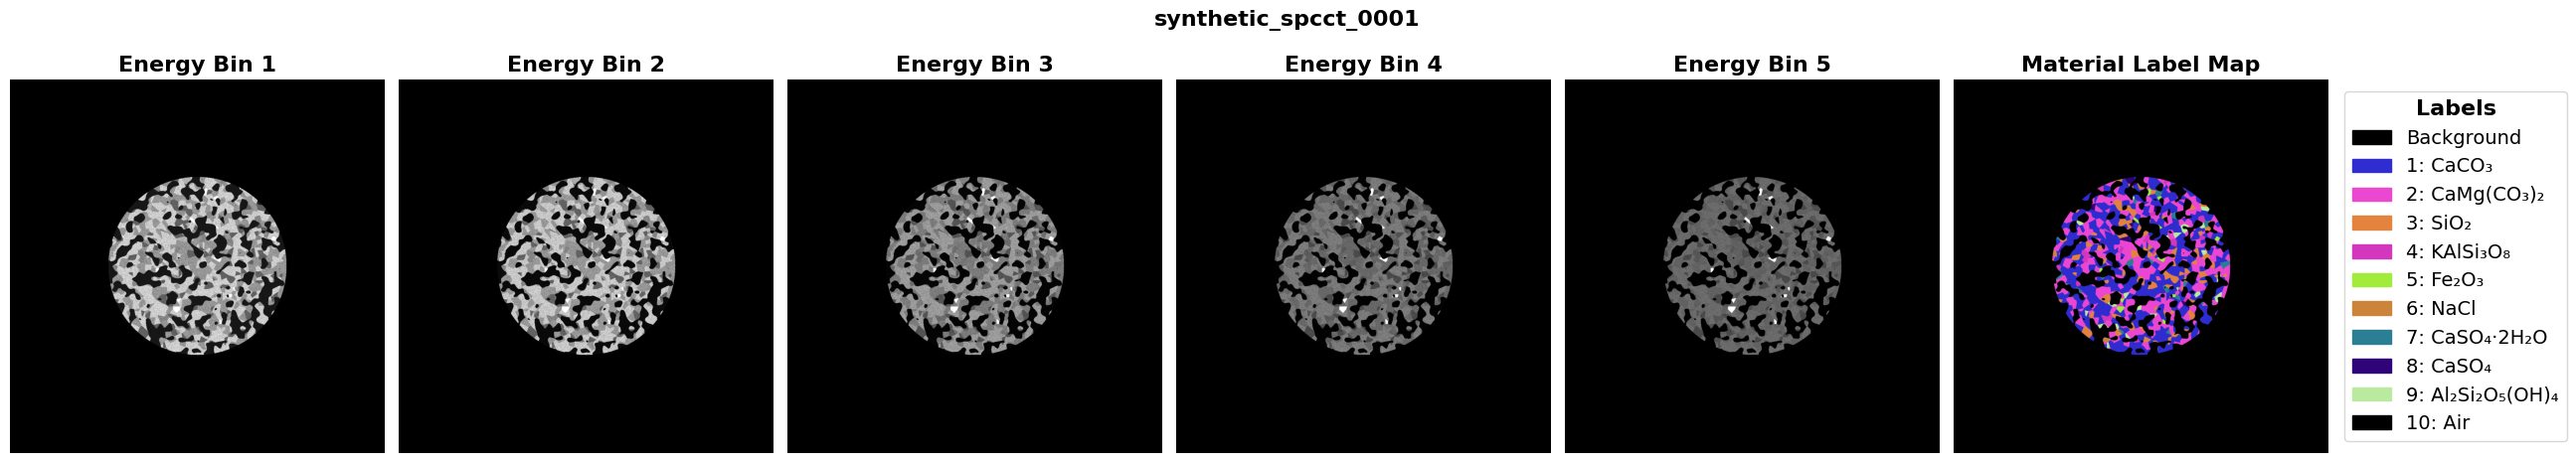

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_five_bins_label_one_row.png


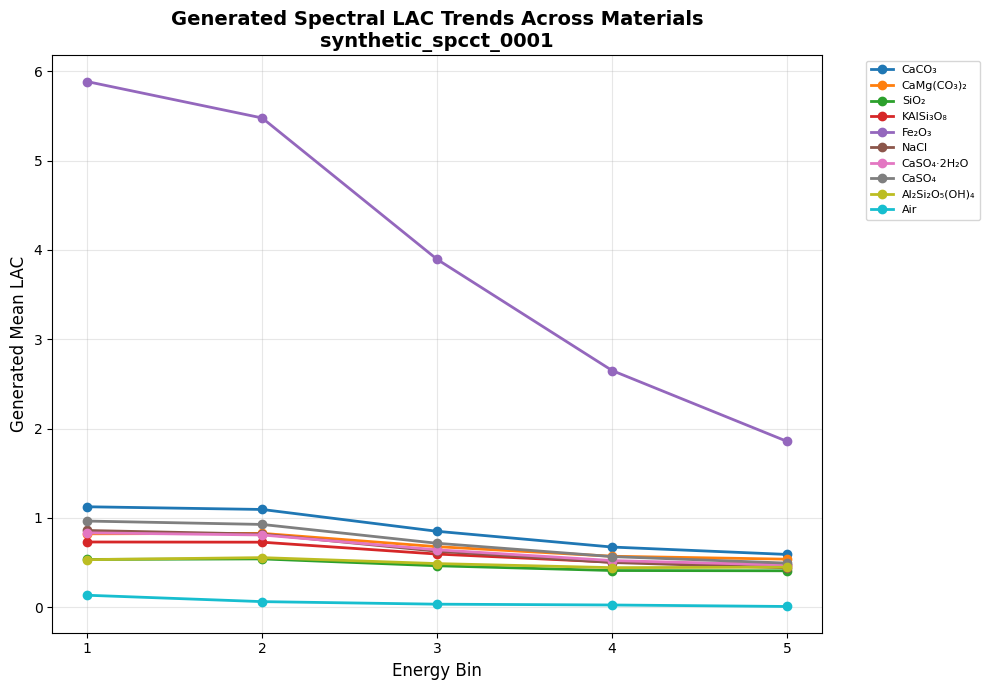

Combined_spectral_plot Saved


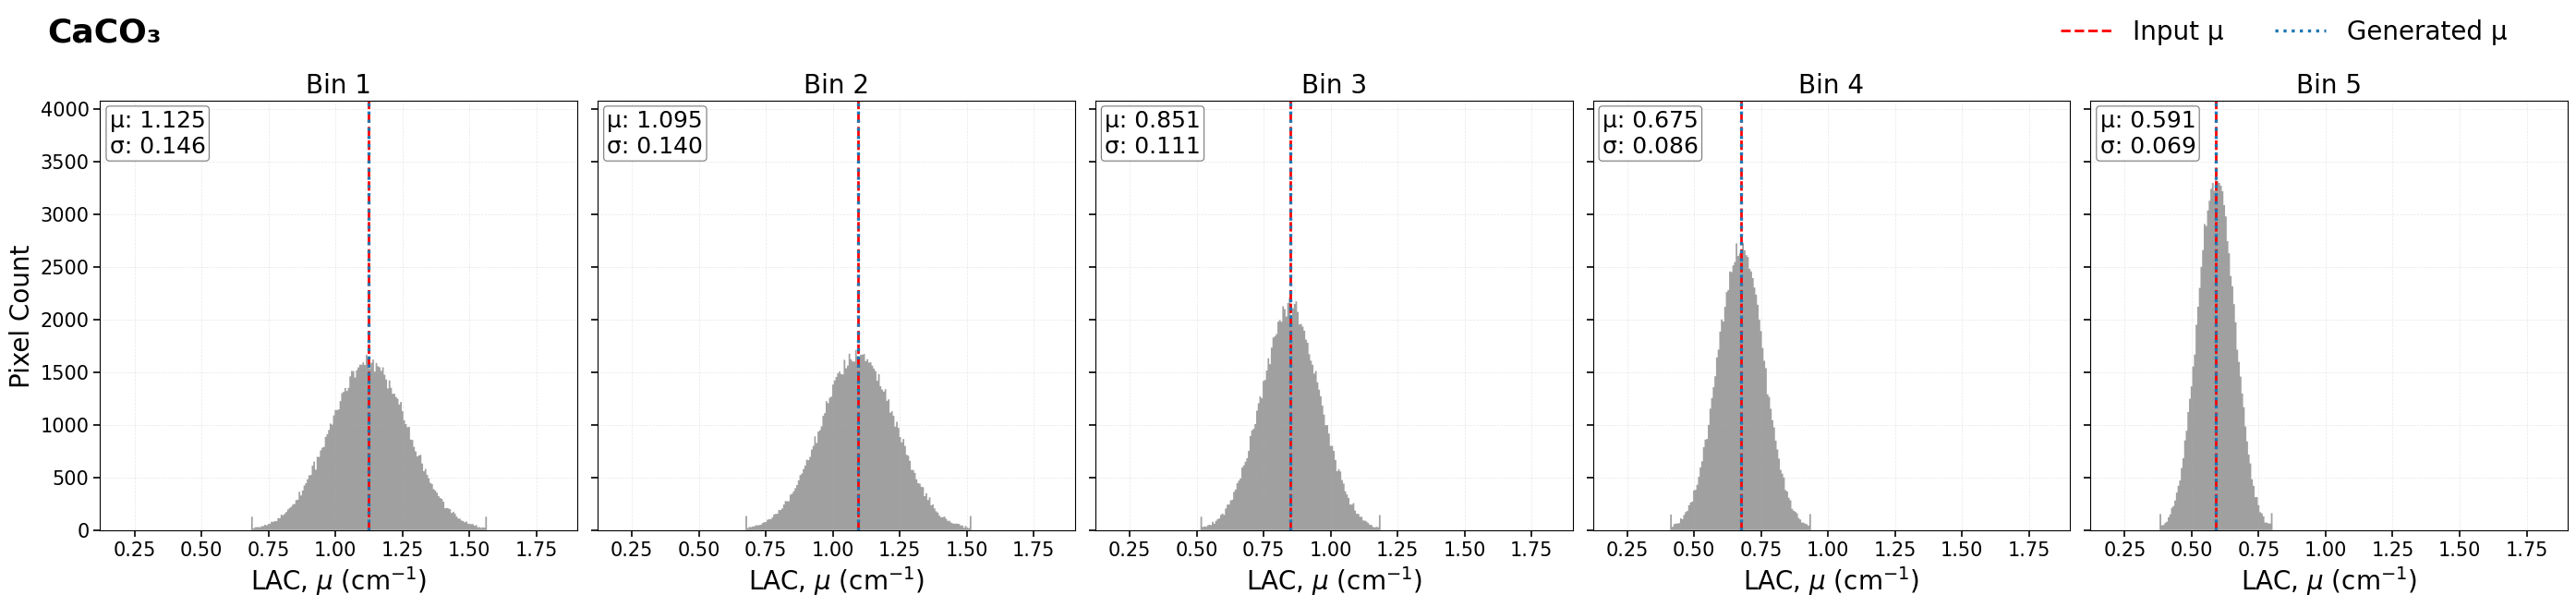

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/CaCO3_synthetic_histogram_5bins.png


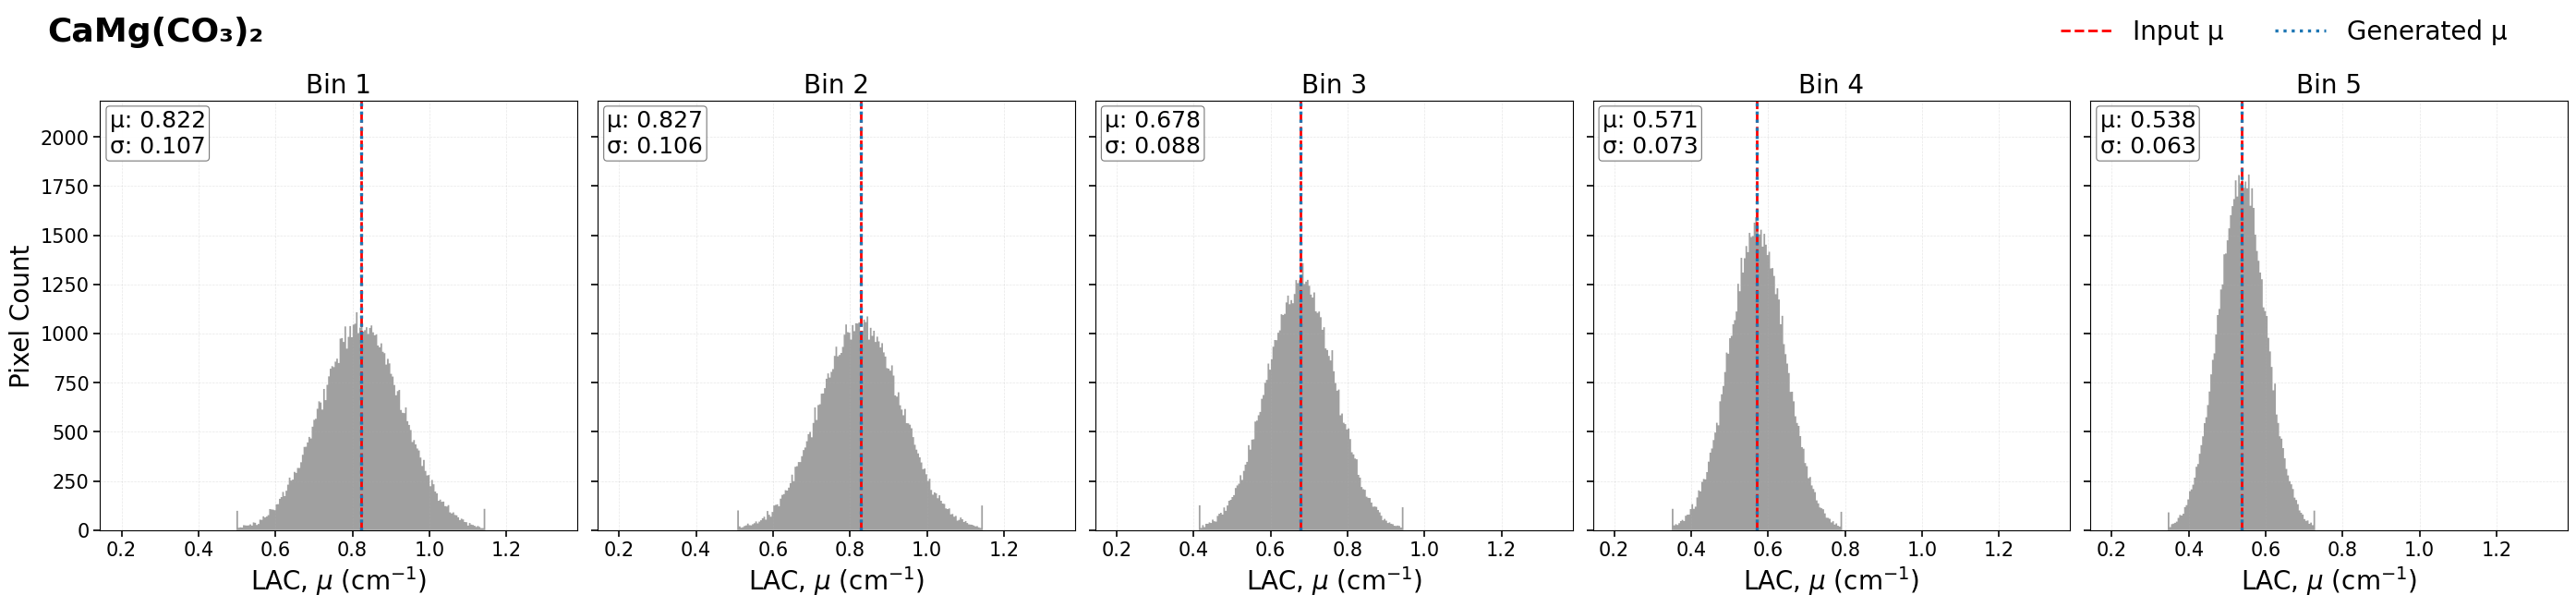

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/CaMgCO32_synthetic_histogram_5bins.png


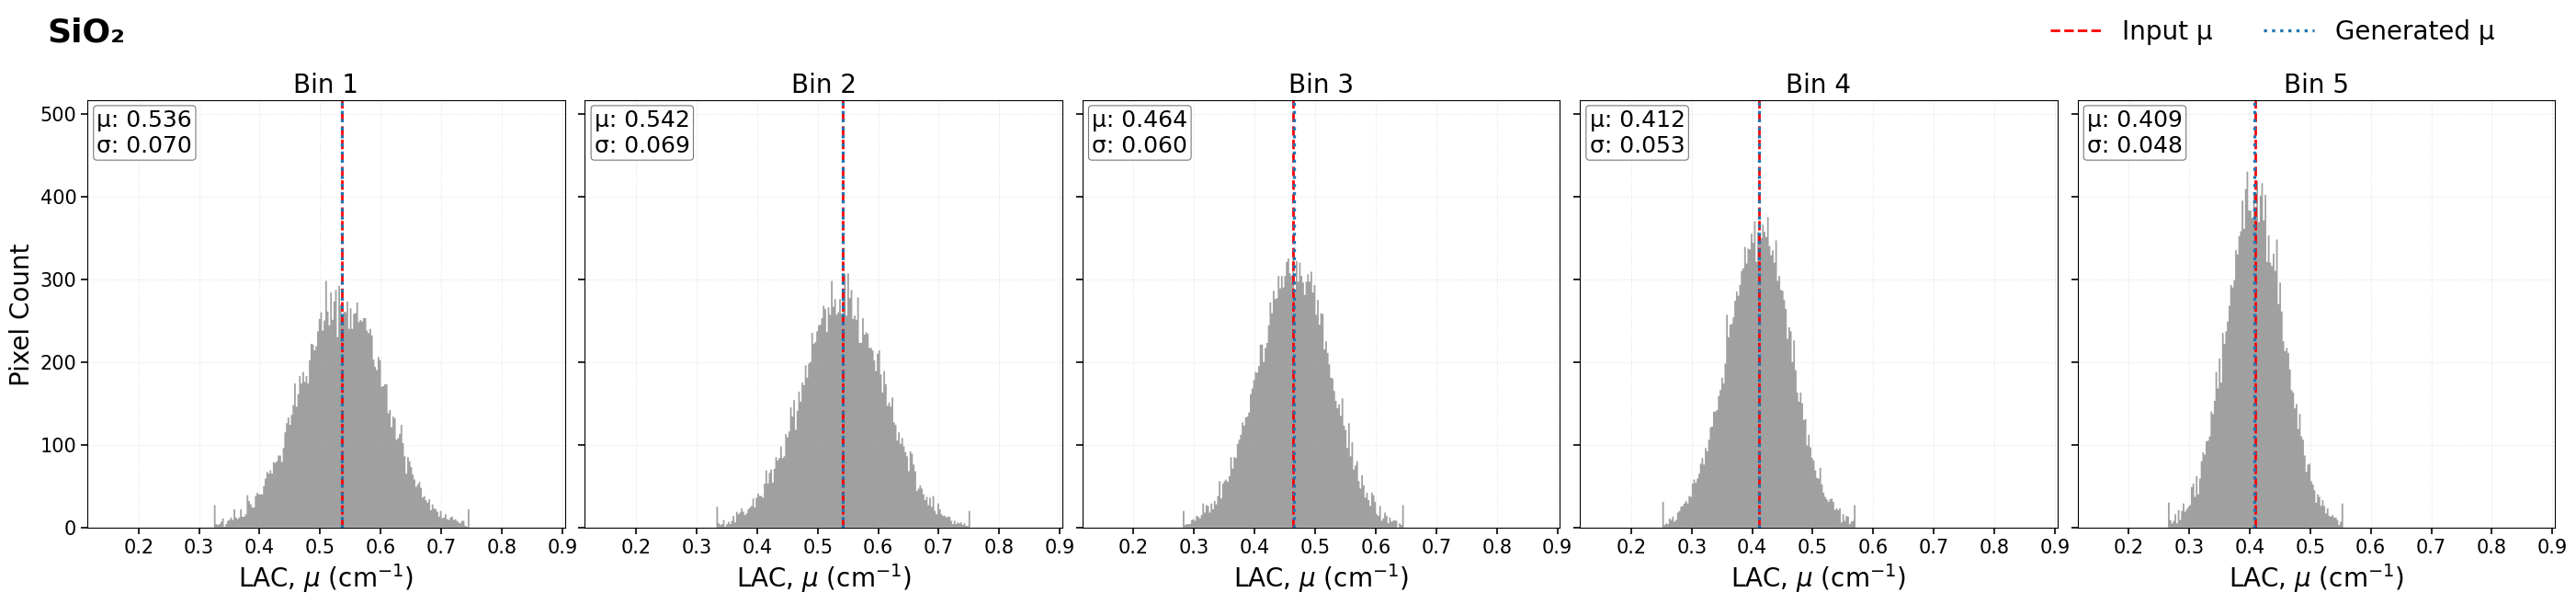

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/SiO2_synthetic_histogram_5bins.png


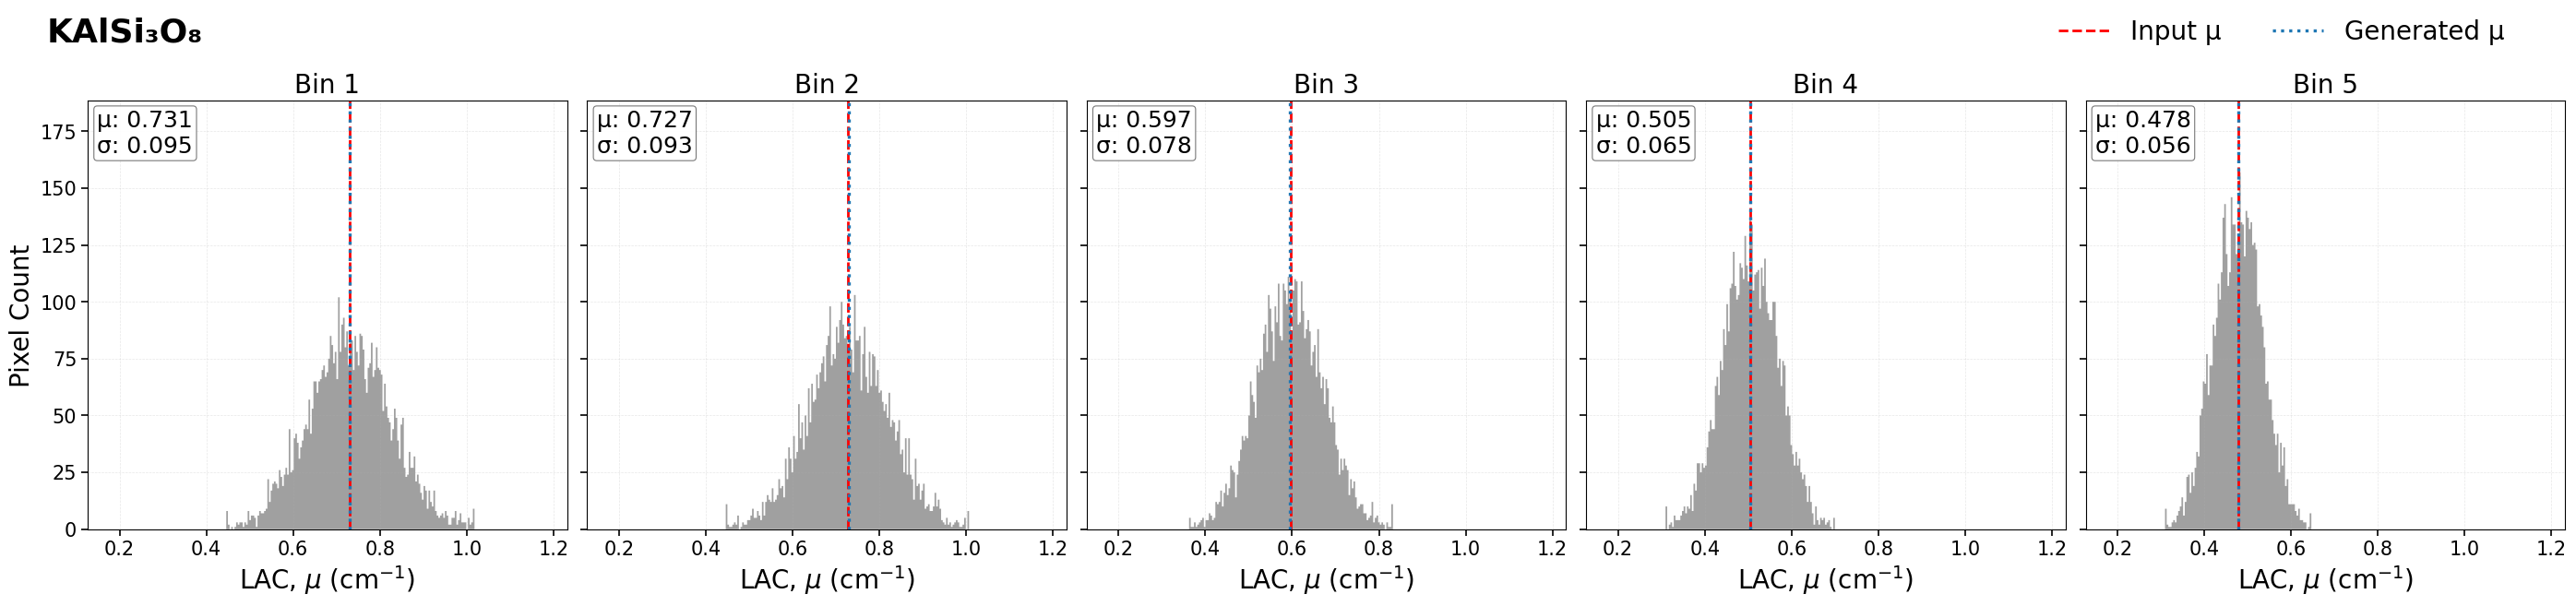

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/KAlSi3O₈_synthetic_histogram_5bins.png


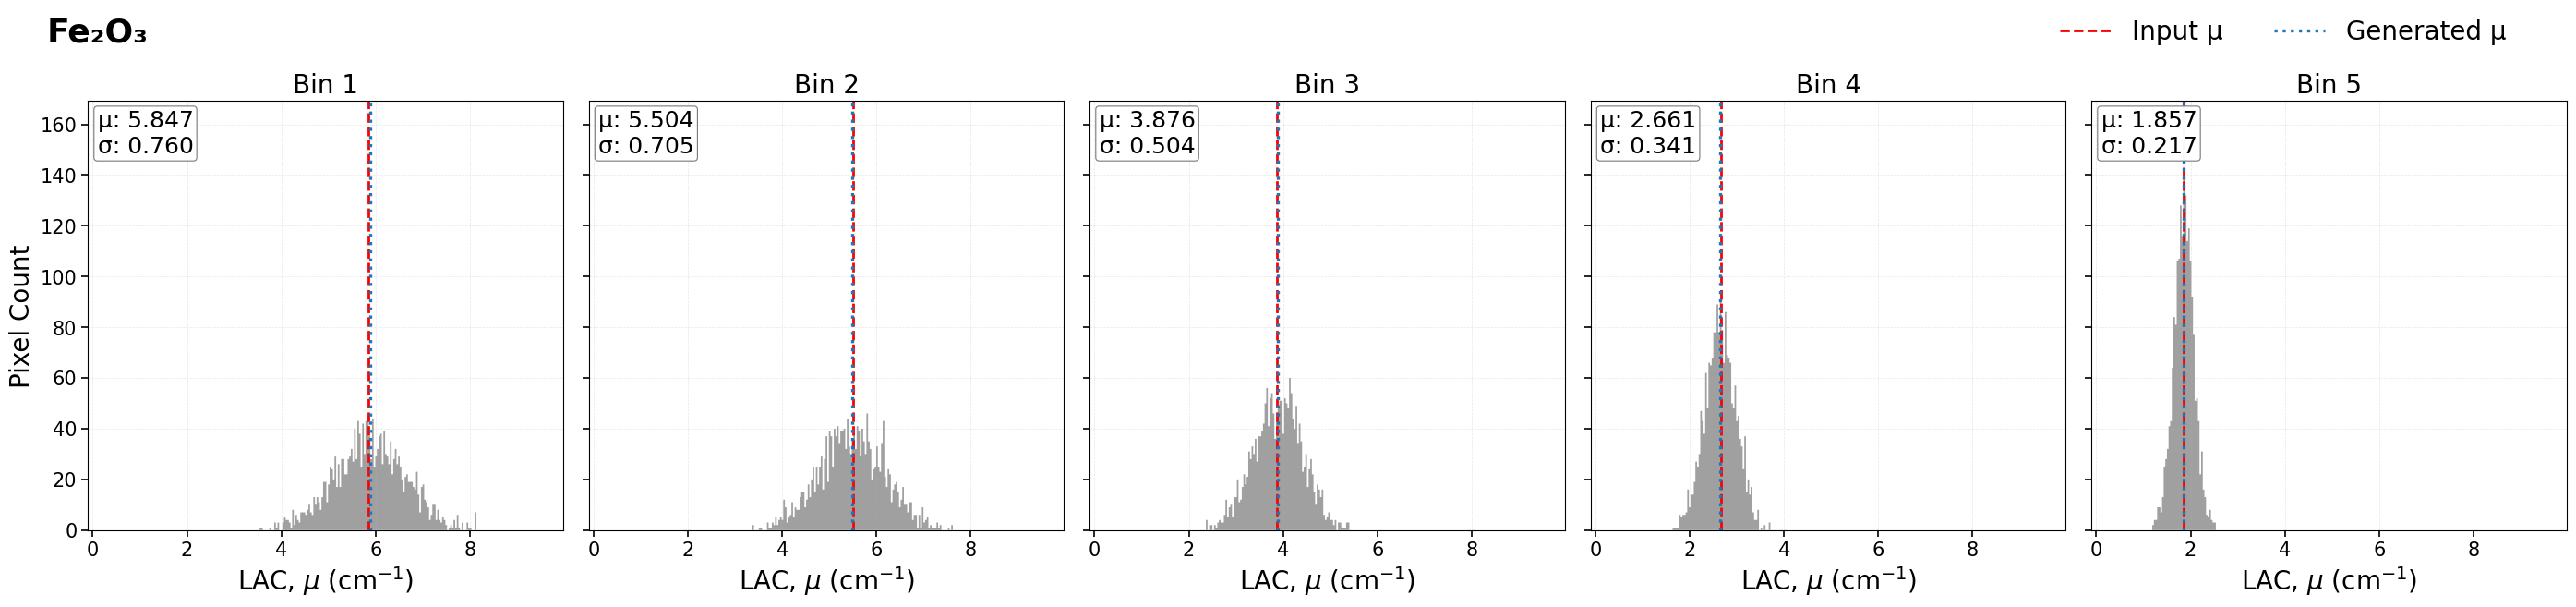

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/Fe2O3_synthetic_histogram_5bins.png


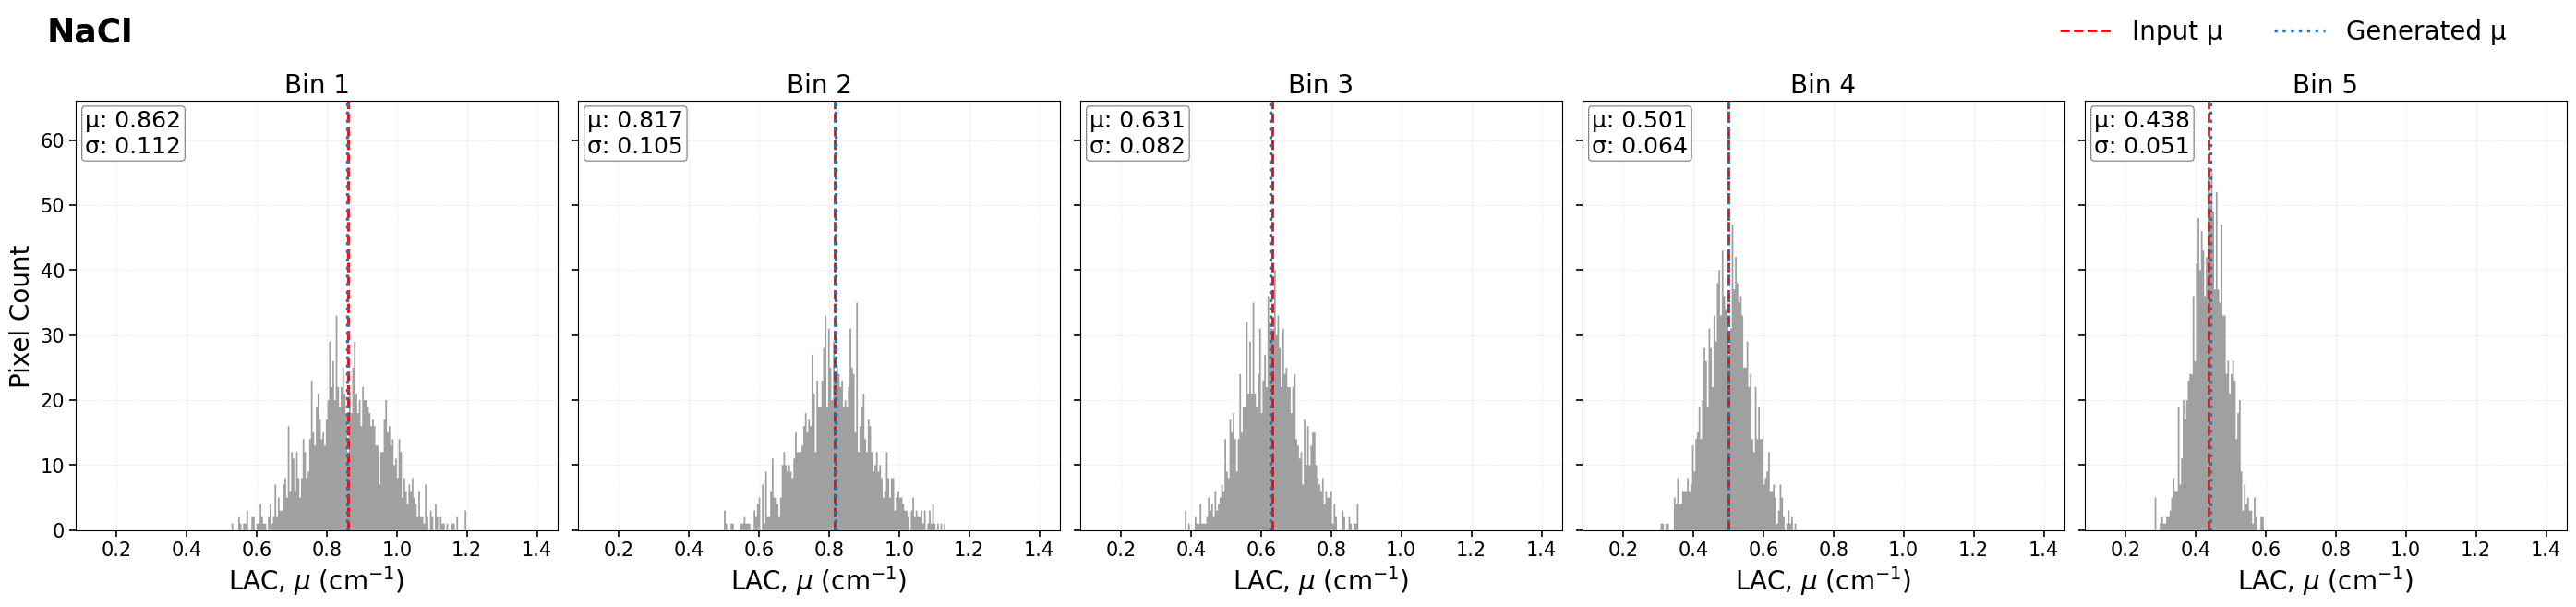

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/NaCl_synthetic_histogram_5bins.png


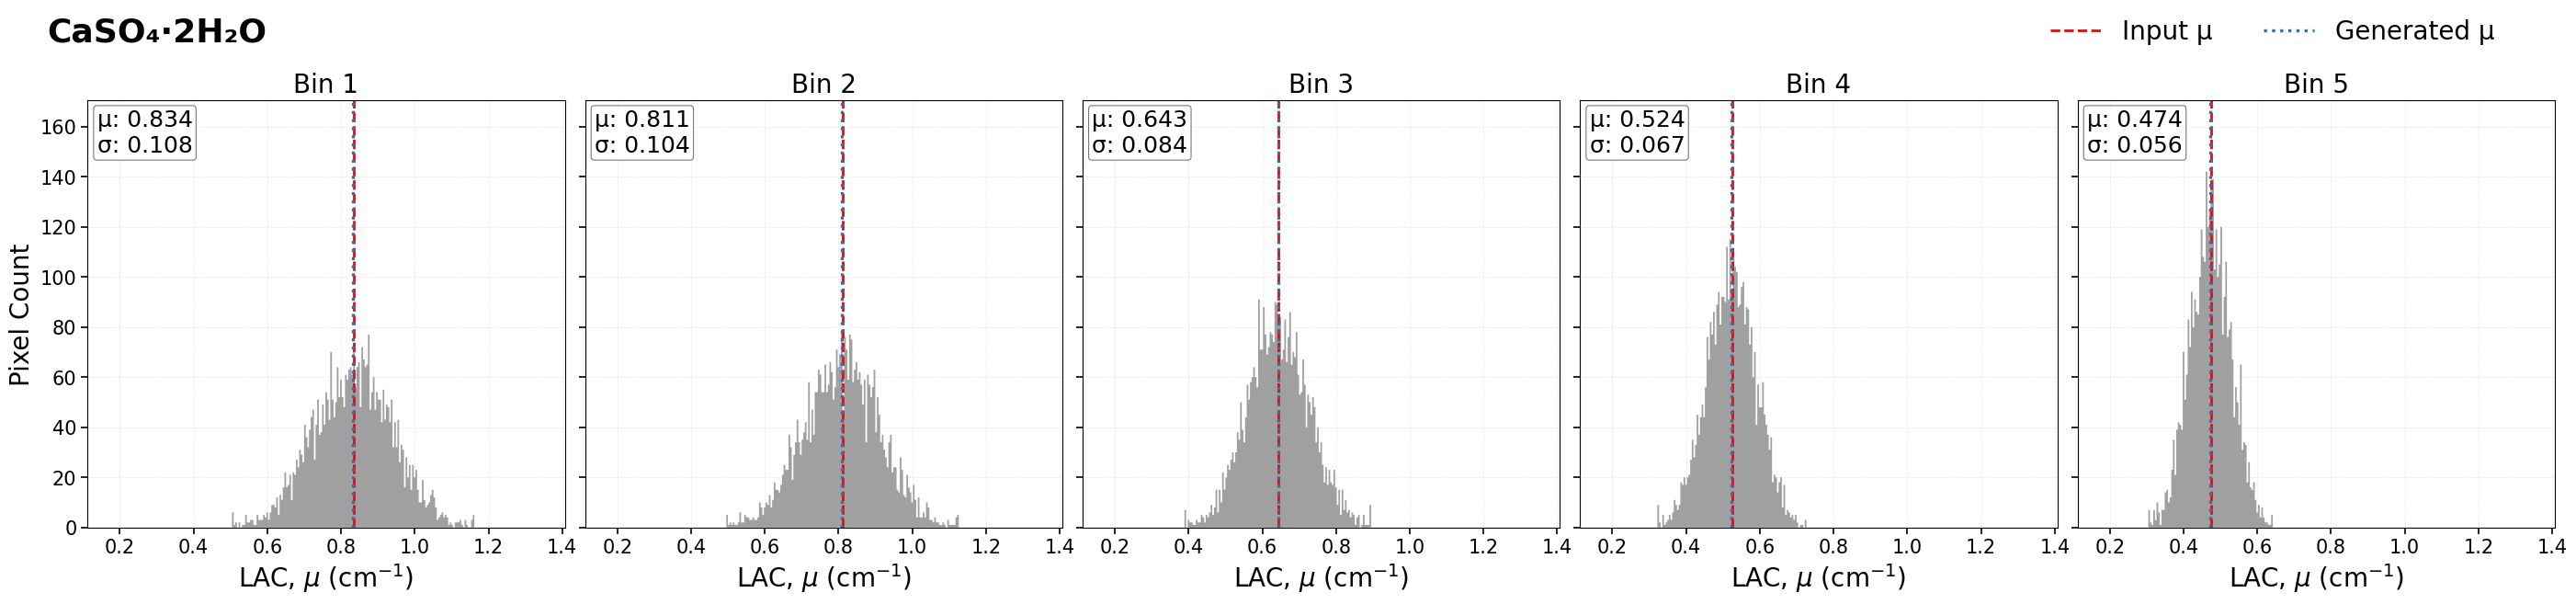

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/CaSO4_2H2O_synthetic_histogram_5bins.png


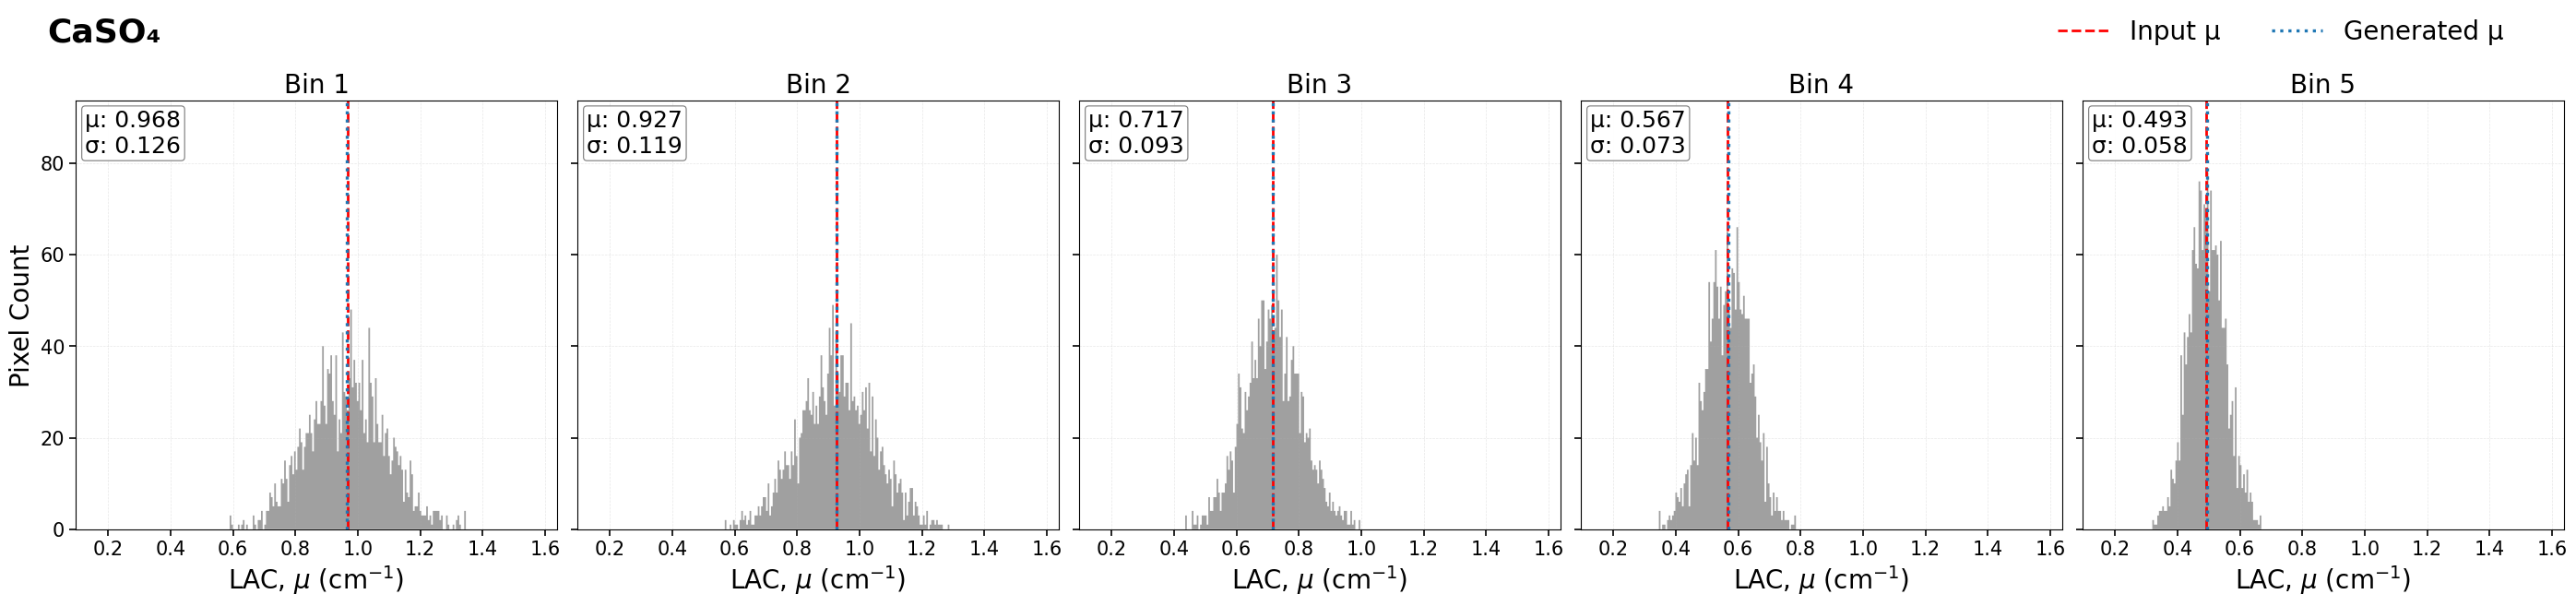

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/CaSO4_synthetic_histogram_5bins.png


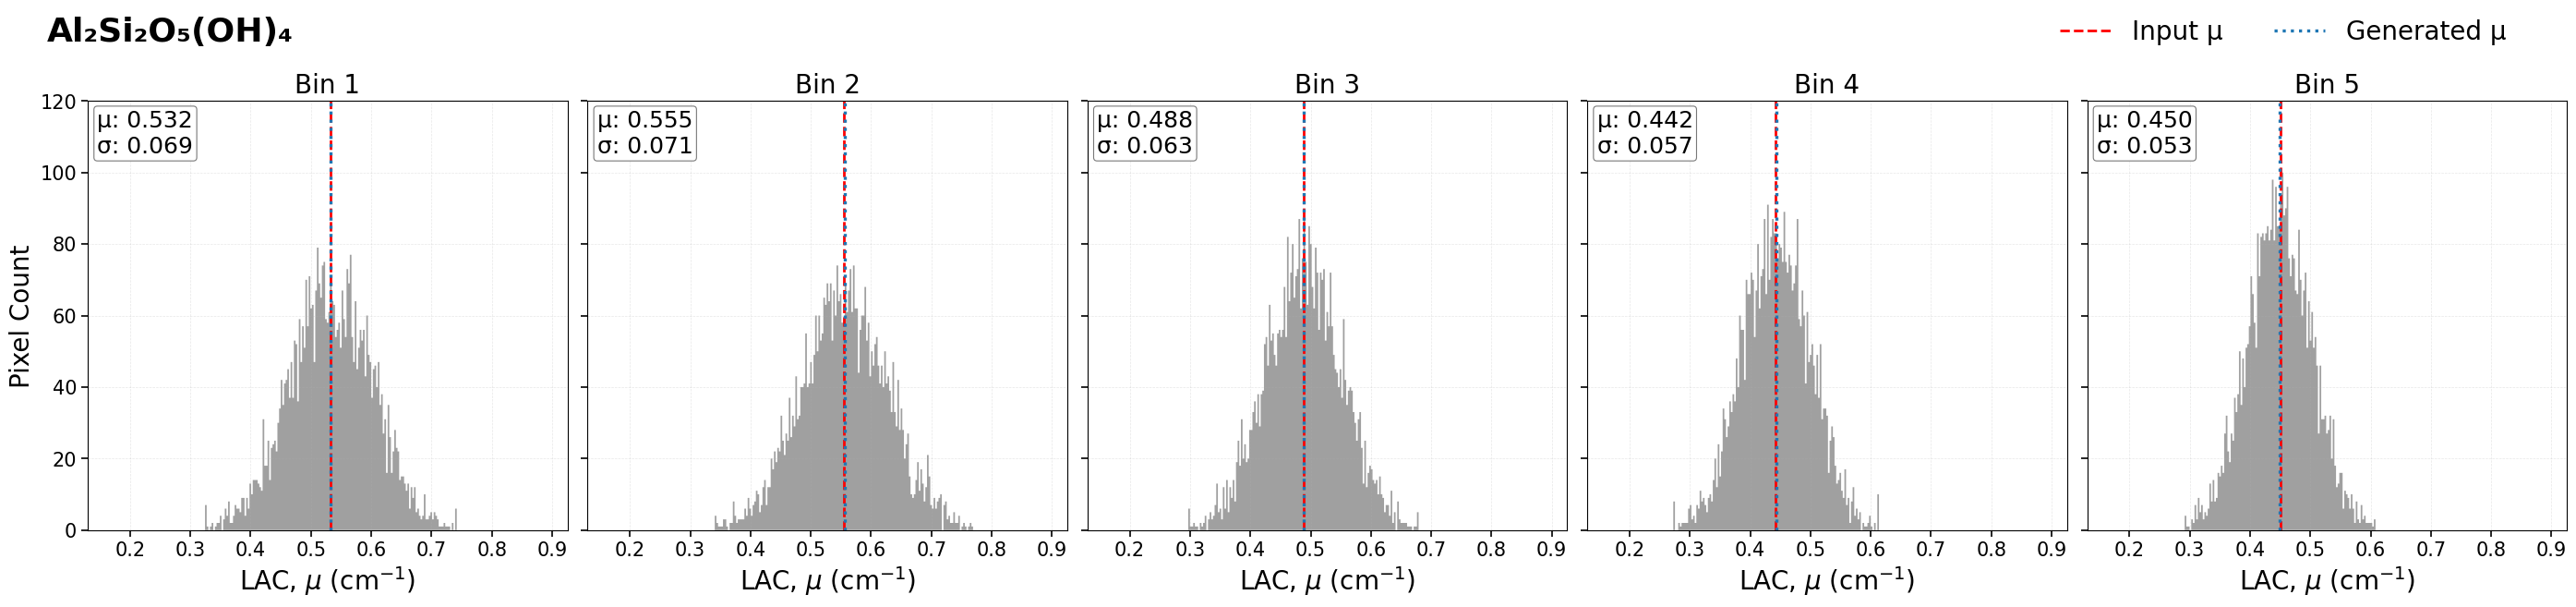

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/Al2Si2O₅OH4_synthetic_histogram_5bins.png


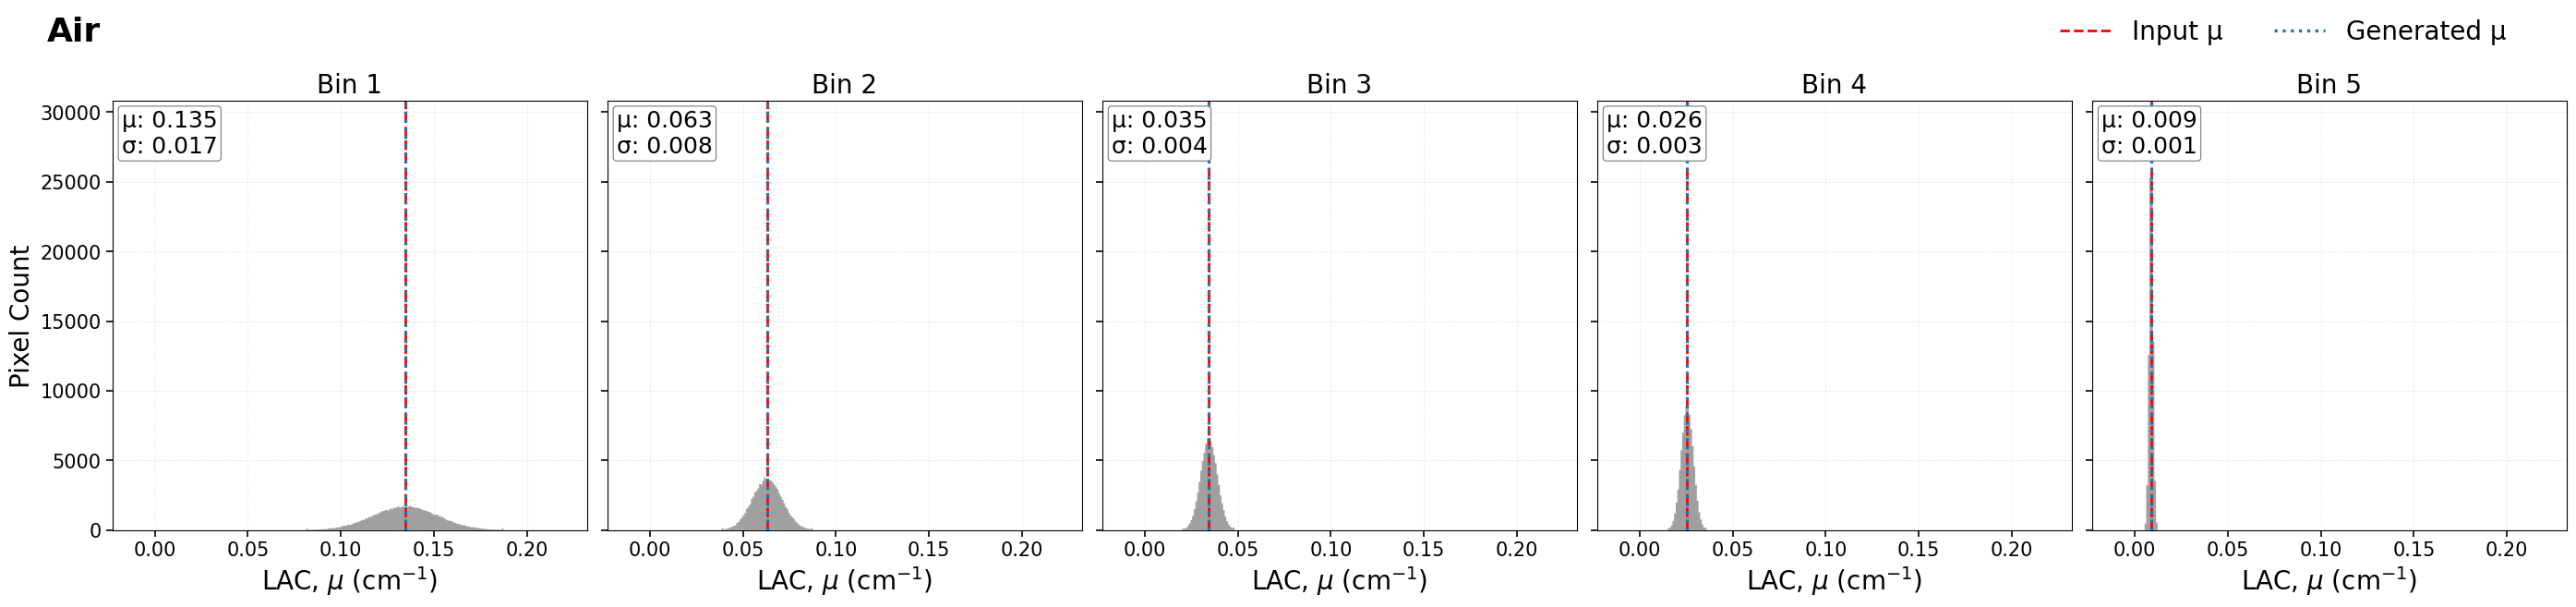

Saved: /content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots/synthetic_spcct_0001_histograms_reference_format/Air_synthetic_histogram_5bins.png
Validation plots saved in:
/content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle/validation_plots


In [28]:
# @title
# ============================================================
# UPDATED CELL 12: VISUAL VALIDATION FOR ONE SELECTED IMAGE
# ============================================================

SELECTED_INDEX = 0

selected_name = f"synthetic_spcct_{SELECTED_INDEX+1:04d}"

selected_image = np.load(
    os.path.join(images_npy_dir, f"{selected_name}.npy")
)

selected_label = np.load(
    os.path.join(labels_npy_dir, f"{selected_name}_label.npy")
)

visualize_selected_image_one_row(
    image=selected_image,
    label_map=selected_label,
    sample_name=selected_name
)

plot_combined_spectral_consistency(
    image=selected_image,
    label_map=selected_label,
    sample_name=selected_name
)

plot_selected_image_histograms_all_materials(
    image=selected_image,
    label_map=selected_label,
    sample_name=selected_name,
    bins=265
)

print("Validation plots saved in:")
print(plots_dir)

**FINAL FILE SPECIFICATION CHECK**

In [29]:
# @title
# ============================================================
# CELL 13: FINAL FILE SPECIFICATION CHECK
# ============================================================

example_tiff = os.path.join(images_tiff_dir, f"{selected_name}.tiff")
example_npy = os.path.join(images_npy_dir, f"{selected_name}.npy")
example_label = os.path.join(labels_npy_dir, f"{selected_name}_label.npy")

spec_report = {
    "Selected_Sample": selected_name,
    "Image_NPY_Shape": list(selected_image.shape),
    "Image_NPY_Dtype": str(selected_image.dtype),
    "Label_NPY_Shape": list(selected_label.shape),
    "Label_NPY_Dtype": str(selected_label.dtype),
    "TIFF_File_Size_MB": os.path.getsize(example_tiff) / (1024 * 1024),
    "NPY_Image_File_Size_MB": os.path.getsize(example_npy) / (1024 * 1024),
    "NPY_Label_File_Size_MB": os.path.getsize(example_label) / (1024 * 1024),
    "Resolution": "10 pixels/mm",
    "Voxel_Size": "0.1 x 0.1 x 0.1 mm^3",
    "Pixel_Spacing": "0.1/0.1 mm",
    "Matrix_Size": "1262 x 1262",
    "Bit_Depth": "32 BPP float",
    "Central_Circle_Radius_pixels": CENTER_RADIUS,
    "Central_Circle_Radius_mm": CENTER_RADIUS * 0.1
}

with open(
    os.path.join(reports_dir, "file_specification_report.json"),
    "w"
) as f:
    json.dump(spec_report, f, indent=4)

print(json.dumps(spec_report, indent=4))

print("\nAll outputs saved at:")
print(OUTPUT_DIR)

{
    "Selected_Sample": "synthetic_spcct_0001",
    "Image_NPY_Shape": [
        5,
        1262,
        1262
    ],
    "Image_NPY_Dtype": "float32",
    "Label_NPY_Shape": [
        1262,
        1262
    ],
    "Label_NPY_Dtype": "int32",
    "TIFF_File_Size_MB": 30.37841033935547,
    "NPY_Image_File_Size_MB": 30.377395629882812,
    "NPY_Label_File_Size_MB": 6.0755767822265625,
    "Resolution": "10 pixels/mm",
    "Voxel_Size": "0.1 x 0.1 x 0.1 mm^3",
    "Pixel_Spacing": "0.1/0.1 mm",
    "Matrix_Size": "1262 x 1262",
    "Bit_Depth": "32 BPP float",
    "Central_Circle_Radius_pixels": 300,
    "Central_Circle_Radius_mm": 30.0
}

All outputs saved at:
/content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle


**DOWNLOAD COMPLETE GENERATED DATASET AS ZIP**

In [ ]:
# @title
# ============================================================
# DOWNLOAD COMPLETE GENERATED DATASET AS ZIP
# ============================================================

import shutil
from google.colab import files

ZIP_PATH = OUTPUT_DIR + ".zip"

print("Creating ZIP file...")

shutil.make_archive(
    base_name=OUTPUT_DIR,
    format='zip',
    root_dir=OUTPUT_DIR
)

print("ZIP file created:")
print(ZIP_PATH)

print("\nStarting download...")

files.download(ZIP_PATH)

Creating ZIP file...
ZIP file created:
/content/SPCCT_Synthetic_Voronoi_Gaussian_Dataset_Circle.zip

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>